In [1]:
# ==========================================
# FULL SCRIPT: PYTORCH END-TO-END DEEP LEARNING
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader
from datasets import load_from_disk
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

In [2]:
# 1. SETUP & DATA LOADING
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("Downloading dataset...")
path = kagglehub.dataset_download("phantrntngvyk64cntt/processed-rsitmd-256-clean")

print("Path to dataset files:", path)
hf_dataset = load_from_disk(path)

# Extract class names safely
try:
    class_names = hf_dataset['train'].features['label'].names
except AttributeError:
    unique_labels = set(hf_dataset['train']['label'])
    class_names = [str(label) for label in sorted(unique_labels)]
num_classes = len(class_names)


Using device: cuda


100%|██████████| 491M/491M [00:04<00:00, 113MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/phantrntngvyk64cntt/processed-rsitmd-256-clean/versions/1


In [3]:
# 2. PREPROCESSING
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def transform_dataset(examples):
    # 1. Create the tensor versions of the images
    examples["pixel_values"] = [preprocess(img.convert("RGB")) for img in examples["image"]]

    # 2. Delete the raw PIL images so the DataLoader doesn't try to batch them
    del examples["image"]

    return examples

# Apply it exactly as before
hf_dataset.set_transform(transform_dataset)

print("Applying transformations dynamically...")

# Replace .map() and .set_format() with .set_transform()
hf_dataset.set_transform(transform_dataset)

# Your DataLoaders remain exactly the same
train_loader = DataLoader(hf_dataset["train"], batch_size=32, shuffle=True)
val_loader = DataLoader(hf_dataset["validation"], batch_size=32, shuffle=False)

Applying transformations dynamically...


In [4]:
# 3. BUILD MODEL
print("Building ResNet50...")
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False # Freeze base

# Add custom head
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)


Building ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]


In [5]:
# ==========================================
# 4. TRAINING & ADVANCED EVALUATION LOOP
# ==========================================
EPOCHS = 10
best_macro_f1 = 0.0 # We will now track the best F1 instead of simple accuracy

print(f"Starting training for {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0

    for batch in train_loader:
        inputs, labels = batch["pixel_values"].to(device), batch["label"].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # --- EVALUATION PHASE ---
    model.eval()

    # Lists to store all predictions and labels for the entire epoch
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in val_loader:
            inputs, labels = batch["pixel_values"].to(device), batch["label"].to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            # Move data back to CPU and add to our lists
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate all three metrics using scikit-learn
    val_acc = accuracy_score(all_labels, all_preds)
    val_bal_acc = balanced_accuracy_score(all_labels, all_preds)
    val_macro_f1 = f1_score(all_labels, all_preds, average='macro')

    # Print the detailed epoch report
    print(f"\nEpoch {epoch+1}/{EPOCHS} Summary:")
    print(f"  Training Loss: {running_loss/len(train_loader):.4f}")
    print(f"  Validation Metrics -> Acc: {val_acc:.4f} | Bal Acc: {val_bal_acc:.4f} | Macro F1: {val_macro_f1:.4f}")

    # Save checkpoint based on the best Macro F1-Score
    if val_macro_f1 > best_macro_f1:
        best_macro_f1 = val_macro_f1
        torch.save(model.state_dict(), "best_resnet50.pt")
        print("  🌟 Checkpoint: New best model saved (based on Macro F1)!")

Starting training for 10 epochs...

Epoch 1/10 Summary:
  Training Loss: 1.9430
  Validation Metrics -> Acc: 0.7314 | Bal Acc: 0.6818 | Macro F1: 0.6891
  🌟 Checkpoint: New best model saved (based on Macro F1)!

Epoch 2/10 Summary:
  Training Loss: 0.8378
  Validation Metrics -> Acc: 0.8075 | Bal Acc: 0.7493 | Macro F1: 0.7532
  🌟 Checkpoint: New best model saved (based on Macro F1)!

Epoch 3/10 Summary:
  Training Loss: 0.6254
  Validation Metrics -> Acc: 0.8090 | Bal Acc: 0.7661 | Macro F1: 0.7701
  🌟 Checkpoint: New best model saved (based on Macro F1)!

Epoch 4/10 Summary:
  Training Loss: 0.5171
  Validation Metrics -> Acc: 0.8012 | Bal Acc: 0.7406 | Macro F1: 0.7434

Epoch 5/10 Summary:
  Training Loss: 0.4404
  Validation Metrics -> Acc: 0.8292 | Bal Acc: 0.7658 | Macro F1: 0.7759
  🌟 Checkpoint: New best model saved (based on Macro F1)!

Epoch 6/10 Summary:
  Training Loss: 0.3933
  Validation Metrics -> Acc: 0.8245 | Bal Acc: 0.7627 | Macro F1: 0.7701

Epoch 7/10 Summary:
  Tr


Generating Confusion Matrix...


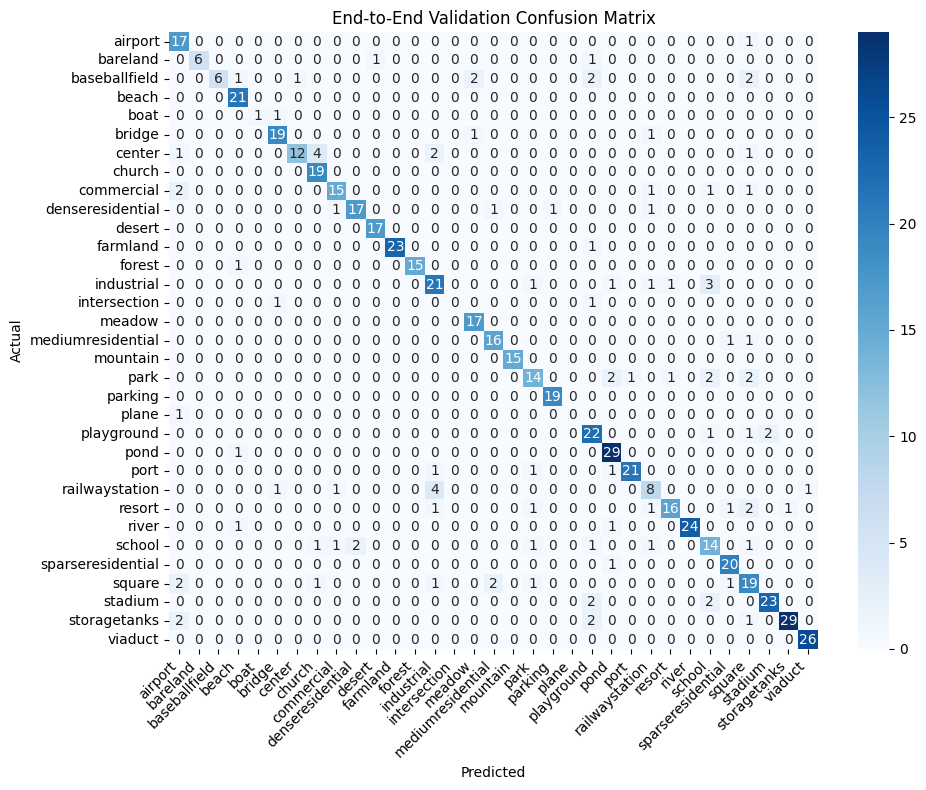

In [6]:
# 5. CONFUSION MATRIX
print("\nGenerating Confusion Matrix...")
model.load_state_dict(torch.load("best_resnet50.pt")) # Load best weights
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in val_loader:
        inputs, labels = batch["pixel_values"].to(device), batch["label"].to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('End-to-End Validation Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()


Generating Prediction, Saliency, and Grad-CAM...


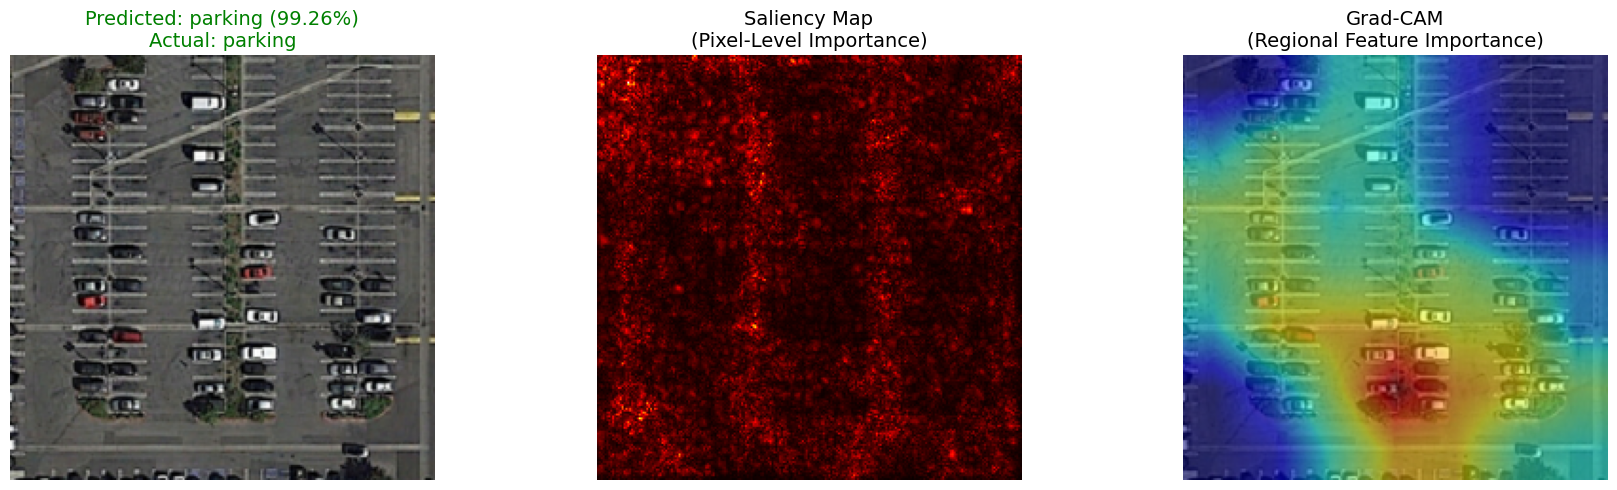

In [7]:
import torch.nn.functional as F

# ==========================================
# STEP 6: TEST ON SINGLE IMAGE + SALIENCY + GRAD-CAM
# ==========================================
print("\nGenerating Prediction, Saliency, and Grad-CAM...")

# 1. Grab a single example
sample_idx = 24
sample = hf_dataset['validation'][sample_idx]
true_label_text = class_names[sample['label']]

# 2. Prepare the image and track gradients
img_tensor = sample['pixel_values'].unsqueeze(0).to(device)
img_tensor.requires_grad_()

# 3. Setup PyTorch Hooks for Grad-CAM
activations = []
gradients = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

# Attach the hooks to the final convolutional block in ResNet50
target_layer = model.layer4[-1]
f_hook = target_layer.register_forward_hook(forward_hook)
b_hook = target_layer.register_full_backward_hook(backward_hook)

# 4. Forward Pass
model.eval()
model.zero_grad()
outputs = model(img_tensor)

probabilities = F.softmax(outputs[0], dim=0)
pred_prob, pred_idx = torch.max(probabilities, 0)
pred_class = class_names[pred_idx.item()]

# 5. Backward Pass
score = outputs[0][pred_idx]
score.backward()

# ==========================================
# PROCESS SALIENCY MAP
# ==========================================
saliency_map, _ = torch.max(img_tensor.grad.data.abs(), dim=1)
saliency_map = saliency_map.squeeze().cpu().numpy()

# ==========================================
# PROCESS GRAD-CAM
# ==========================================
captured_grads = gradients[0]
captured_acts = activations[0]

weights = torch.mean(captured_grads, dim=[2, 3], keepdim=True)
cam = torch.sum(weights * captured_acts, dim=1, keepdim=True)
cam = F.relu(cam)

cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
cam = cam.squeeze().cpu().detach().numpy()
cam = (cam - cam.min()) / (cam.max() - cam.min())

f_hook.remove()
b_hook.remove()

# ==========================================
# PROCESS ORIGINAL IMAGE (FIX COLORS)
# ==========================================
# Un-normalize the tensor to restore the true colors
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# Reverse the math and clamp values between 0 and 1
unnormalized_tensor = sample['pixel_values'].cpu() * std + mean
unnormalized_tensor = torch.clamp(unnormalized_tensor, 0, 1)

# Convert to a human-readable image
raw_image = transforms.ToPILImage()(unnormalized_tensor)

# ==========================================
# VISUALIZE EVERYTHING
# ==========================================
plt.figure(figsize=(18, 5))

# Plot 1: True Original Image
plt.subplot(1, 3, 1)
plt.imshow(raw_image)
plt.title(f"Predicted: {pred_class} ({pred_prob.item()*100:.2f}%)\nActual: {true_label_text}",
          color='green' if pred_class == true_label_text else 'red', fontsize=14)
plt.axis('off')

# Plot 2: Saliency Map
plt.subplot(1, 3, 2)
plt.imshow(saliency_map, cmap='hot')
plt.title("Saliency Map\n(Pixel-Level Importance)", fontsize=14)
plt.axis('off')

# Plot 3: Grad-CAM Overlay
plt.subplot(1, 3, 3)
plt.imshow(raw_image)
plt.imshow(cam, cmap='jet', alpha=0.5)
plt.title("Grad-CAM\n(Regional Feature Importance)", fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()